In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('../data/noise_data.csv')

# Encode categorical columns
le_zone = LabelEncoder()
le_day = LabelEncoder()
df['zone_encoded'] = le_zone.fit_transform(df['zone_type'])
df['day_encoded'] = le_day.fit_transform(df['day_of_week'])

# Features and target
X = df[['hour','day_encoded','zone_encoded','traffic_density','nearby_events','temperature','wind_speed']]
y = df['noise_db']

# Split 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (3500, 7), Val: (750, 7), Test: (750, 7)


In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("=== Random Forest Results ===")
print(f"MAE:  {rf_mae:.3f} dB")
print(f"RMSE: {rf_rmse:.3f} dB")
print(f"R²:   {rf_r2:.3f}")

=== Random Forest Results ===
MAE:  2.625 dB
RMSE: 3.332 dB
R²:   0.955


In [3]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("=== XGBoost Results ===")
print(f"MAE:  {xgb_mae:.3f} dB")
print(f"RMSE: {xgb_rmse:.3f} dB")
print(f"R²:   {xgb_r2:.3f}")

=== XGBoost Results ===
MAE:  2.525 dB
RMSE: 3.199 dB
R²:   0.958


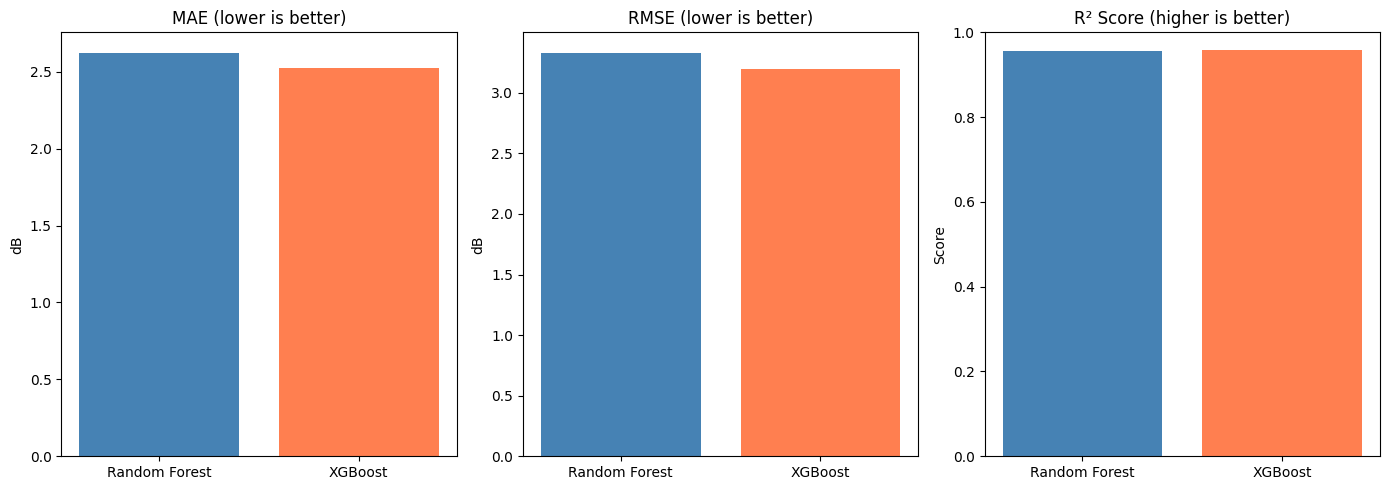

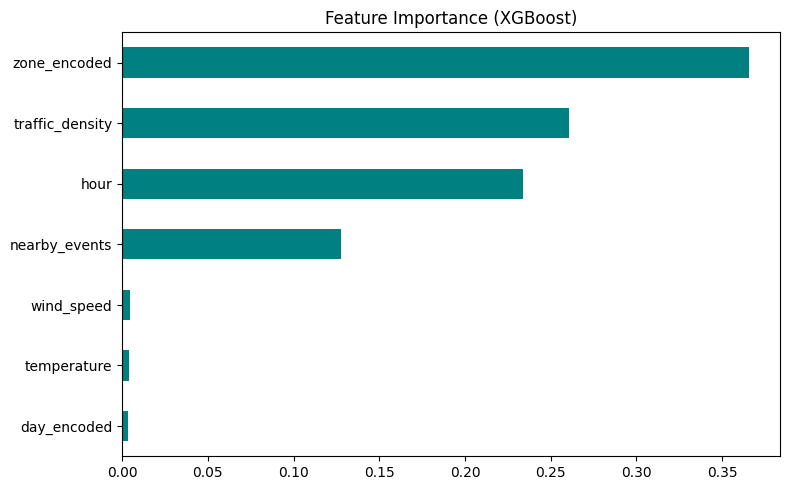


Best model: XGBoost


In [4]:
import matplotlib.pyplot as plt

# Comparison bar chart
models = ['Random Forest', 'XGBoost']
maes   = [rf_mae, xgb_mae]
rmses  = [rf_rmse, xgb_rmse]
r2s    = [rf_r2, xgb_r2]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].bar(models, maes, color=['steelblue','coral'])
axes[0].set_title('MAE (lower is better)'); axes[0].set_ylabel('dB')

axes[1].bar(models, rmses, color=['steelblue','coral'])
axes[1].set_title('RMSE (lower is better)'); axes[1].set_ylabel('dB')

axes[2].bar(models, r2s, color=['steelblue','coral'])
axes[2].set_title('R² Score (higher is better)'); axes[2].set_ylabel('Score')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../data/model_comparison.png', dpi=150)
plt.show()

# Feature importance from XGBoost
feat_imp = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(8,5))
feat_imp.plot(kind='barh', color='teal')
plt.title('Feature Importance (XGBoost)')
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150)
plt.show()

print(f"\nBest model: {'XGBoost' if xgb_r2 > rf_r2 else 'Random Forest'}")

In [5]:
import joblib

joblib.dump(rf, '../models/random_forest.pkl')
joblib.dump(xgb, '../models/xgboost_model.pkl')

# Save encoder too (needed for the dashboard later)
joblib.dump(le_zone, '../models/le_zone.pkl')
joblib.dump(le_day, '../models/le_day.pkl')

print("All models saved!")

All models saved!
